In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("diabetes_data.csv", sep=";")
df = pd.get_dummies(df)
X = df.drop('class', axis=1)
y = df['class']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [3]:
dt_model = DecisionTreeClassifier(criterion='entropy', random_state=42)
dt_model.fit(X_train, y_train)

,criterion,'entropy'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [4]:
y_pred = dt_model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9711538461538461
              precision    recall  f1-score   support

           0       0.92      1.00      0.96        33
           1       1.00      0.96      0.98        71

    accuracy                           0.97       104
   macro avg       0.96      0.98      0.97       104
weighted avg       0.97      0.97      0.97       104



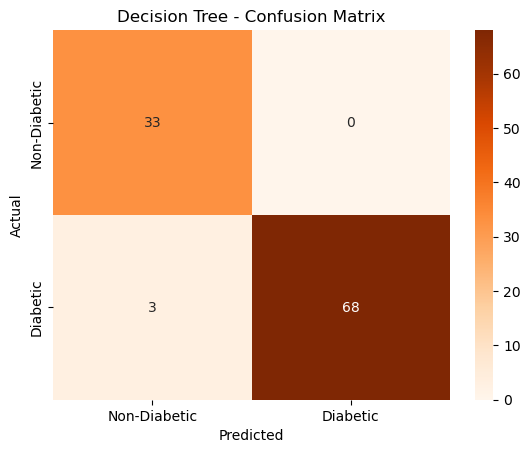

In [5]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Non-Diabetic','Diabetic'],
            yticklabels=['Non-Diabetic','Diabetic'])
plt.title("Decision Tree - Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

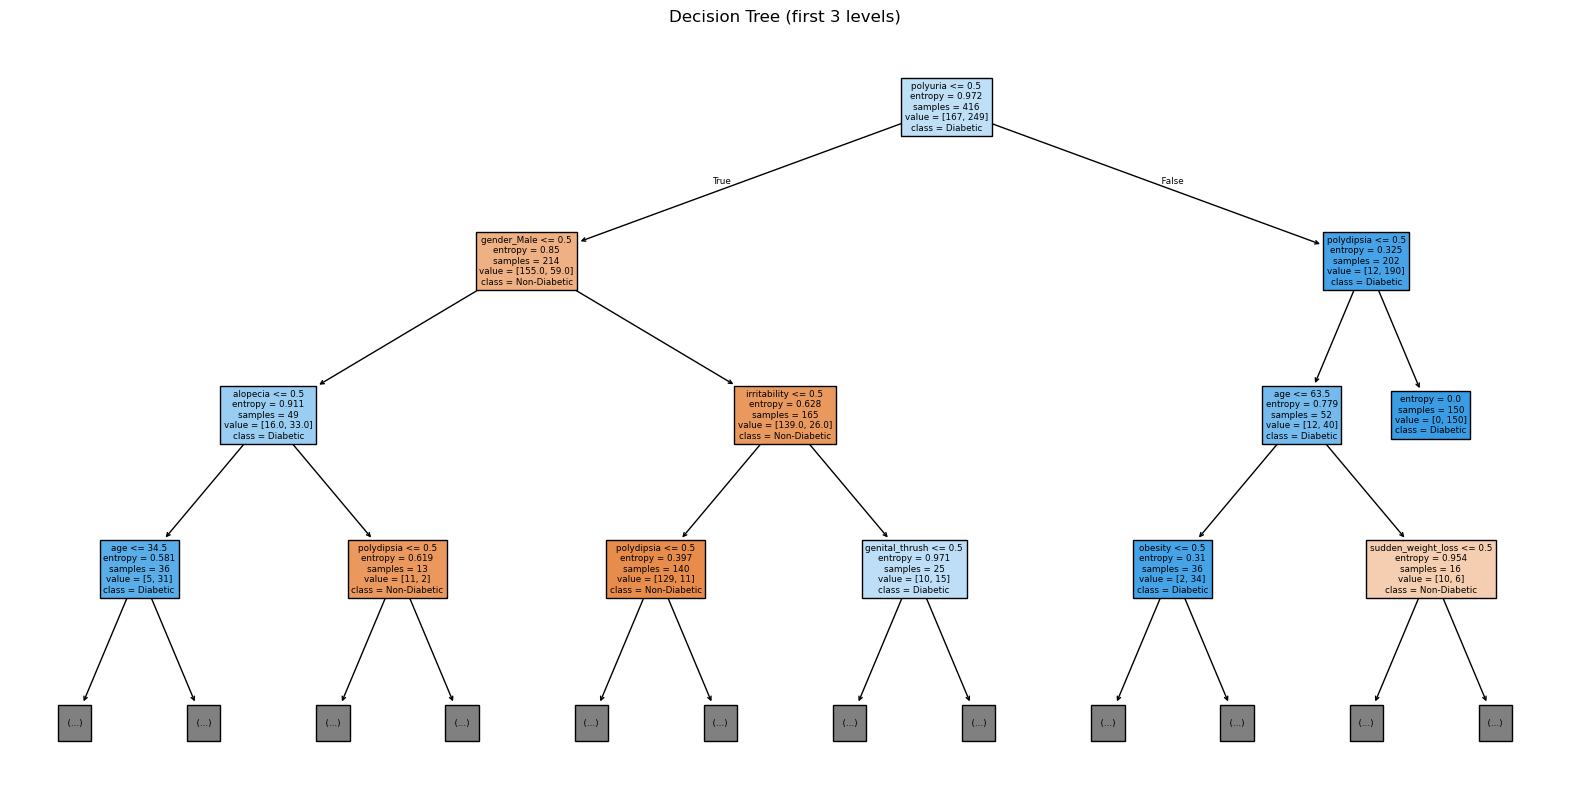

In [6]:
plt.figure(figsize=(20, 10))
plot_tree(dt_model, feature_names=X.columns,
          class_names=['Non-Diabetic', 'Diabetic'],
          filled=True, max_depth=3)
plt.title("Decision Tree (first 3 levels)")
plt.show()

In [7]:
cv_scores = cross_val_score(dt_model, X, y, cv=10, scoring='accuracy')
print(f"Mean CV Accuracy: {cv_scores.mean()*100:.2f}%")

Mean CV Accuracy: 96.15%


In [8]:
from sklearn.metrics import precision_score, recall_score, f1_score

print("="*40)
print("        PERFORMANCE METRICS")
print("="*40)
print(f"Accuracy  : {accuracy_score(y_test, y_pred)*100:.2f}%")
print(f"Precision : {precision_score(y_test, y_pred)*100:.2f}%")
print(f"Recall    : {recall_score(y_test, y_pred)*100:.2f}%")
print(f"F1 Score  : {f1_score(y_test, y_pred)*100:.2f}%")
print("="*40)

        PERFORMANCE METRICS
Accuracy  : 97.12%
Precision : 100.00%
Recall    : 95.77%
F1 Score  : 97.84%


In [9]:
import joblib

model = DecisionTreeClassifier(criterion='entropy', random_state=42)
model.fit(X_train, y_train)

joblib.dump(model, "decision_tree.pkl")
print("Saved successfully")

Saved successfully
